In [47]:
# Loading 
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from sympy import symbols, diff, solve, lambdify
from sympy.physics.quantum.tensorproduct import TensorProduct



In [48]:
# Variables of the master muscle
r_ia  = symbols('r_ia ')
phi_a = symbols('phi_a')
lbd_a = symbols('lbd_a')
R_a   = symbols('R_a  ')
p_a   = symbols('p_a  ')
# Design parameters of the master muscle
L_a     = 0.035
R_ia    = 0.00035
R_oa    = 0.0023
Theta_a = 0
mu_1a   = 427560
mu_2a   = 8500000
alpha_a = 1.44
# Variables of the slave muscle
r_ib  = symbols('r_ib')
phi_b = symbols('phi_b')
lbd_b = symbols('lbd_b')
R_b   = symbols('R_b')
p_b   = symbols('p_b')
# Design parameters of the slave muscle
L_b     = 0.0125
R_ib    = 0.0002
R_ob    = 0.0007
Theta_b = 0
mu_1b   = 235680
mu_2b   = 8500000
alpha_b = 1.44

In [49]:
def df_grad_tensor(R, R_i, r_i, lbd, phi, alpha, L):
    # Define the function f(ri, phi, R, lambda) using sympy
    # Deformation gradient tensor
    r = sp.sqrt((R**2-R_i**2)/lbd + r_i**2)
    F = sp.Matrix([[R/(r*lbd), 0, 0], [0, r/R, r*phi/L], [0, 0, lbd]])
    S = sp.Matrix([[0], [sp.sin(alpha)], [sp.cos(alpha)]])
    # print("Deformation Gradient Tensor F:")
    # sp.pprint(F)
    # print("\nDirection Vector s:")
    # sp.pprint(S)
    # Calculate the Cauchy-Green deformation tensor C
    s = F * S
    # sp.pprint(s_a)
    return F, s

In [50]:
F_a, s_a = df_grad_tensor(R_a, R_ia, r_ia, lbd_a, phi_a, alpha_a, L_a)
F_b, s_b = df_grad_tensor(R_b, R_ib, r_ib, lbd_b, phi_b, alpha_b, L_b)

In [51]:
# First and fourth invariants of master muscle
I1_a = sp.trace(sp.MatMul(F_a, F_a.T))
I4_a = sp.MatMul(s_a.T, s_a)   
I4_a = I4_a[0,0]

# First and fourth invariants of slave muscle
I1_b = sp.trace(sp.MatMul(F_b, F_b.T))
I4_b = sp.MatMul(s_b.T, s_b)
I4_b = I4_b[0, 0]

In [52]:
# Master muscle hyperelastic and fiber energy function
sigma_tube_a  = mu_1a * sp.MatMul(F_a, F_a.T) 
sigma_coil_a  = mu_2a * TensorProduct(s_a, s_a.T) * (sp.sqrt(I4_a) - 1) / sp.sqrt(I4_a) 
sigma_total_a = sigma_tube_a + sigma_coil_a - (p_a * sp.eye(3))
sp.shape(sigma_total_a)

# Slave muscle hyperelastic and fiber energy function
sigma_tube_b  = mu_1b * sp.MatMul(F_b, F_b.T) 
sigma_coil_b  = mu_2b * TensorProduct(s_b, s_b.T) * (sp.sqrt(I4_b) - 1) / sp.sqrt(I4_b) 
sigma_total_b = sigma_tube_b + sigma_coil_b - (p_b * sp.eye(3))
sp.shape(sigma_total_b)

(3, 3)

In [53]:
# Equilibrium function of connecting master and slave muscles
# function 1: The volume inside the master and slave muscles totally is constant
f1             = L_a * lbd_a * r_ia ** 2 + L_b * lbd_b * r_ib ** 2 - L_a * R_ia ** 2 - L_b * R_ib ** 2
print("Function 1")
df1_dr_ia      = diff(f1, r_ia  )
df1_phi_b      = diff(f1, phi_b )
df1_dr_ib      = diff(f1, r_ib  )
df1_dlbd_b     = diff(f1, lbd_b )

# function 2: There is no external load applied on slave muscle
f2_dot         = np.pi * R_b/lbd_b * (2 * sigma_total_b[2,2] - sigma_total_b[0,0] - sigma_total_b[1,1])
print("Function 2")
sp.pprint(f2_dot)
df2_dot_dr_ia  = diff(f2_dot, r_ia )
df2_dot_dphi_b = diff(f2_dot, phi_b )
df2_dot_dr_ib  = diff(f2_dot, r_ib  )
df2_dot_dlbd_b = diff(f2_dot, lbd_b )

# function 3: There is no external torque applied on slave muscle
r_b            = sp.sqrt((R_b**2-R_ib**2)/lbd_b + r_ib**2)
f3_dot         = sigma_total_b[1,2] * r_b * R_b / lbd_b * 2 * np.pi
print("Function 3")
sp.pprint(f3_dot)
df3_dot_dr_ia  = diff(f3_dot, r_ia  )
df3_dot_dphi_b = diff(f3_dot, phi_b )
df3_dot_dr_ib  = diff(f3_dot, r_ib  )
df3_dot_dlbd_b = diff(f3_dot, lbd_b )

# function 4: Fluid pressure in master muscle is equal to the pressure of fluid in slave muscle
f4a_dot        = R_a / (R_a**2 - R_ia**2 + lbd_a*r_ia**2) * (sigma_total_a[1,1] - sigma_total_a[0,0])
f4b_dot        = R_b / (R_b**2 - R_ib**2 + lbd_b*r_ib**2) * (sigma_total_b[1,1] - sigma_total_b[0,0])
print("Function 4a")
sp.pprint(f4a_dot)
print("Function 4b")
sp.pprint(f4b_dot)
df4a_dot_dr_ia = diff(f4a_dot, r_ia )
df4b_dot_dr_ib = diff(f4b_dot, r_ib )
df4b_dot_dlbd_b= diff(f4b_dot, lbd_b)
df4b_dot_dphi_b= diff(f4b_dot, phi_b)


Function 1
Function 2
                     ⎛                                                         ↪
                     ⎜                                                         ↪
                     ⎜                                                         ↪
                     ⎜                                                         ↪
                     ⎜                                                         ↪
                     ⎜                                                         ↪
                     ⎜                                                         ↪
                     ⎜                     2                             28917 ↪
                     ⎜           235680⋅R_b                          2         ↪
3.14159265358979⋅R_b⋅⎜- ────────────────────────────── + 471360⋅lbd_b  + ───── ↪
                     ⎜         ⎛           2         ⎞                         ↪
                     ⎜       2 ⎜    2   R_b  - 4.0e-8⎟                         ↪
      

In [54]:
# Initialize values for Newton-Raphson method
lbd_init = 1.5
phi_init = 0.5
ri_init = 0.0005
subs_init = {lbd_a: lbd_init, phi_a: phi_init, r_ia: ri_init}
tolerance = 1e-6
max_iterations = 100


In [55]:
# Numerical evaluation of the integrals
def numerical_integral(func, R, x_start, x_end, num_points=100):
    x_values = np.linspace(x_start, x_end, num_points, dtype=np.float64)
    y_values = np.array([func.subs(R, x).evalf() for x in x_values])
    integral = np.sum(y_values) * (x_end - x_start) / num_points
    return integral


In [69]:
# analytical integral for pressure and load and moment
def Jacobian_matrix ( f1, f2_dot, f3_dot, f4a_dot, f4b_dot, r_ia, r_ib, lbd_b, phi_b, current_val, R_ia, R_oa, R_ib, R_ob):
    ''' 
        f1, f2_dot, f3_dot, f4a_dot, f4b_dot: Equilibrium functions
        r_ia: Symbolic radius of master muscle
        r_ib: Symbolic radius of slave muscle
        lbd_b: Elongation of slave muscle
        phi_b: Twist angle of slave muscle
        current_val ndarray(6,0): Substitute value for variables in below function
            - [0]: r_ia
            - [1]: phi_a
            - [2]: lbd_a
            - [3]: r_ib
            - [4]: phi_b
            - [5]: lbd_b
    '''
    # Equilibrium function of connecting master and slave muscles
    # function 1: The volume inside the master and slave muscles totally is constant
    df1_dr_ia      = diff(f1, r_ia  )
    df1_dphi_b     = diff(f1, phi_b )
    df1_dr_ib      = diff(f1, r_ib  )
    df1_dlbd_b     = diff(f1, lbd_b )

    # function 2: There is no external load applied on slave muscle
    df2_dot_dr_ia  = diff(f2_dot, r_ia )
    df2_dot_dphi_b = diff(f2_dot, phi_b )
    df2_dot_dr_ib  = diff(f2_dot, r_ib  )
    df2_dot_dlbd_b = diff(f2_dot, lbd_b )

    # function 3: There is no external torque applied on slave muscle
    df3_dot_dr_ia  = diff(f3_dot, r_ia  )
    df3_dot_dphi_b = diff(f3_dot, phi_b )
    df3_dot_dr_ib  = diff(f3_dot, r_ib  )
    df3_dot_dlbd_b = diff(f3_dot, lbd_b )

    # function 4: Fluid pressure in master muscle is equal to the pressure of fluid in slave muscle
    df4a_dot_dr_ia = diff(f4a_dot, r_ia )
    df4b_dot_dr_ib = diff(f4b_dot, r_ib )
    df4b_dot_dlbd_b= diff(f4b_dot, lbd_b)
    df4b_dot_dphi_b= diff(f4b_dot, phi_b)

    subs_val = [(r_ia, current_val[0]), (phi_a, current_val[1]), (lbd_a, current_val[2]), (r_ib, current_val[3]), (phi_b, current_val[4]), (lbd_b, current_val[5])]
    f1_subs  = f1.subs(subs_val).evalf()
    df1_dr_ia_subs = df1_dr_ia.subs(subs_val).evalf()
    df1_dr_ib_subs = df1_dr_ib.subs(subs_val).evalf()
    df1_dphi_b_subs= df1_dphi_b.subs(subs_val).evalf()
    df1_dlbd_b_subs= df1_dlbd_b.subs(subs_val).evalf()
    
    # F2 processing ===================================================
    f2_dot_subs  = f2_dot.subs(subs_val)
    df2_dot_dr_ia_subs = df2_dot_dr_ia.subs(subs_val)
    df2_dot_dr_ib_subs = df2_dot_dr_ib.subs(subs_val)
    df2_dot_dphi_b_subs= df2_dot_dphi_b.subs(subs_val)
    df2_dot_dlbd_b_subs= df2_dot_dlbd_b.subs(subs_val)

    f2_subs            = numerical_integral(f2_dot_subs, R_b, R_ib, R_ob)
    df2_dr_ia_subs     = numerical_integral(df2_dot_dr_ia_subs , R_b, R_ib, R_ob)
    df2_dr_ib_subs     = numerical_integral(df2_dot_dr_ib_subs , R_b, R_ib, R_ob)
    df2_dphi_b_subs    = numerical_integral(df2_dot_dphi_b_subs, R_b, R_ib, R_ob)
    df2_dlbd_b_subs    = numerical_integral(df2_dot_dlbd_b_subs, R_b, R_ib, R_ob)

    # F3 processing ====================================================

    f3_dot_subs  = f3_dot.subs(subs_val)
    df3_dot_dr_ia_subs = df3_dot_dr_ia.subs(subs_val)
    df3_dot_dr_ib_subs = df3_dot_dr_ib.subs(subs_val)
    df3_dot_dphi_b_subs= df3_dot_dphi_b.subs(subs_val)
    df3_dot_dlbd_b_subs= df3_dot_dlbd_b.subs(subs_val)

    f3_subs            = numerical_integral(f3_dot_subs, R_b, R_ib, R_ob)
    df3_dr_ia_subs     = numerical_integral(df3_dot_dr_ia_subs , R_b, R_ib, R_ob)
    df3_dr_ib_subs     = numerical_integral(df3_dot_dr_ib_subs , R_b, R_ib, R_ob)
    df3_dphi_b_subs    = numerical_integral(df3_dot_dphi_b_subs, R_b, R_ib, R_ob)
    df3_dlbd_b_subs    = numerical_integral(df3_dot_dlbd_b_subs, R_b, R_ib, R_ob)

    # F4 processing

    f4a_dot_subs        = f4a_dot.subs(subs_val)
    f4b_dot_subs        = f4b_dot.subs(subs_val)

    df4a_dot_dr_ia_subs = df4a_dot_dr_ia.subs(subs_val)
    df4b_dot_dr_ib_subs = df4b_dot_dr_ib.subs(subs_val)
    df4b_dot_dphi_b_subs= df4b_dot_dphi_b.subs(subs_val)
    df4b_dot_dlbd_b_subs= df4b_dot_dlbd_b.subs(subs_val)

    f4_subs            = numerical_integral(f4a_dot_subs, R_a, R_ia, R_oa) - numerical_integral(f4b_dot_subs, R_b, R_ib, R_ob)
    df4_dr_ia_subs     = numerical_integral(df4a_dot_dr_ia_subs , R_a, R_ia, R_oa)
    df4_dr_ib_subs     = - numerical_integral(df4b_dot_dr_ib_subs , R_b, R_ib, R_ob) 
    df4_dphi_b_subs    = - numerical_integral(df4b_dot_dphi_b_subs, R_b, R_ib, R_ob)
    df4_dlbd_b_subs    = - numerical_integral(df4b_dot_dlbd_b_subs, R_b, R_ib, R_ob)
    # seperate into thread into threads to speed up the computation of the integrals      

    J = np.array([[df1_dr_ia_subs, df1_dr_ib_subs, df1_dphi_b_subs, df1_dlbd_b_subs],
                  [df2_dr_ia_subs, df2_dr_ib_subs, df2_dphi_b_subs, df2_dlbd_b_subs],
                  [df3_dr_ia_subs, df3_dr_ib_subs, df3_dphi_b_subs, df3_dlbd_b_subs],
                  [df4_dr_ia_subs, df4_dr_ib_subs, df4_dphi_b_subs, df4_dlbd_b_subs]], dtype=np.float64)
    
    return J, f1_subs, f2_subs, f3_subs, f4_subs

# Newton-Raphson iteration
def newton_raphson(f1, f2_dot, f3_dot, f4a_dot, f4b_dot, r_ia, r_ib, lbd_b, phi_b, input_val, R_ia, R_oa, R_ib, R_ob, lr=0.05, max_iterations=100, tolerance=0.0001):
    current_val = np.zeros(6)
    current_val[1:3] = input_val
    current_val[0]  = 0.00035
    current_val[3]  = 0.0002
    current_val[5]  = 1.0

    f1_history = []
    f2_history = []
    f3_history = []
    f4_history = []
    for i in range(max_iterations):
        
        J, f1_subs, f2_subs, f3_subs, f4_subs = Jacobian_matrix(f1, f2_dot, f3_dot, f4a_dot, f4b_dot, r_ia, r_ib, lbd_b, phi_b, current_val, R_ia, R_oa, R_ib, R_ob)
        print(J)
        F = np.array([f1_subs, f2_subs, f3_subs, f4_subs], dtype=np.float64)
        print("Cost:", F)
        f1_history.append(f1_subs)
        f2_history.append(f2_subs)
        f3_history.append(f3_subs)
        f4_history.append(f4_subs)
        delta = -np.dot(np.linalg.inv(J), F)
        current_val[0] += lr * delta[0]
        current_val[3:5] += lr * delta[1:3]
        current_val[-1] += lr * 10 * delta[-1]
        # Display the current iteration and the values of ri, phi, lambda
        print(f"Iteration {i+1:8d}: r_ia = {current_val[0]:10.7f}, r_ib = {current_val[3]:10.7f}, phi_b = {current_val[4]:10.7f}, lambda_b = {current_val[5]:10.7f}")
        if np.linalg.norm(delta) < tolerance:
            print(f"Convergence achieved after {i+1} iterations.")
            break
    return current_val, [f1_history, f2_history, f3_history, f4_history]

In [70]:
# Test with

input_val = np.array([0.0, 1.5])
func_hist = []

robot_config, func_hist = newton_raphson(f1, f2_dot, f3_dot, f4a_dot, f4b_dot, r_ia, r_ib, lbd_b, phi_b, input_val, R_ia, R_oa, R_ib, R_ob, lr=0.05, max_iterations=100, tolerance=0.0000001)

[[ 3.67500000e-05  5.00000000e-06  0.00000000e+00  5.00000000e-10]
 [ 0.00000000e+00 -6.25910379e+03 -2.93280396e-02  3.07900561e+00]
 [ 0.00000000e+00  6.78857721e-01  1.13771696e-05 -2.98714723e-04]
 [ 1.14376337e+10 -2.14039954e+10 -4.32174248e+04  2.84043699e+06]]
Cost: [ 2.14375000e-09  0.00000000e+00  0.00000000e+00 -1.32767188e+06]
Iteration        1: r_ia =  0.0003480, r_ib =  0.0001943, phi_b =  0.0482473, lambda_b =  0.8877586
[[ 3.65418916e-05  4.31123345e-06  0.00000000e+00  4.71675439e-10]
 [ 0.00000000e+00 -7.07506338e+03 -3.83646460e-02  4.81758442e+00]
 [ 0.00000000e+00  6.84981752e-01  1.25280413e-05 -4.04616861e-04]
 [ 1.14870741e+10 -2.33298940e+10 -5.05740332e+04  3.97720164e+06]]
Cost: [ 1.98985223e-09 -3.97551094e-01  3.57457114e-05 -1.60256369e+06]
Iteration        2: r_ia =  0.0003459, r_ib =  0.0001892, phi_b =  0.0848817, lambda_b =  0.8577123
[[ 3.63226904e-05  4.05694462e-06  0.00000000e+00  4.47450421e-10]
 [ 0.00000000e+00 -7.13652596e+03 -4.11449530e-02  

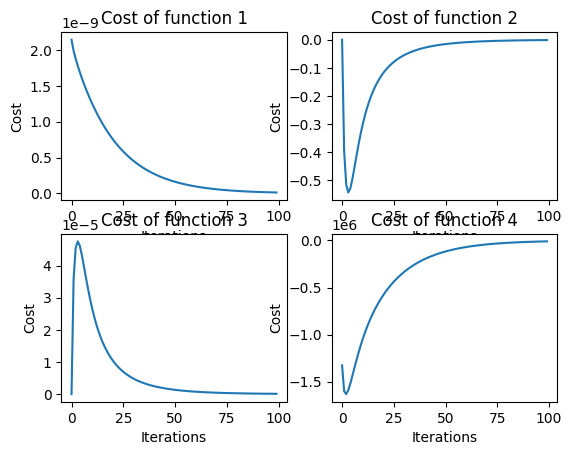

In [71]:
# Plot differences of tube configuration respect to input pressure
plt.subplot(2,2,1)
plt.plot(func_hist[0] )
plt.title("Cost of function 1")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.subplot(2,2,2)
plt.plot(func_hist[1] )
plt.title("Cost of function 2")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.subplot(2,2,3)
plt.plot(func_hist[2] )
plt.title("Cost of function 3")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.subplot(2,2,4)
plt.plot(func_hist[3] )
plt.title("Cost of function 4")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.show()



In [75]:
print(f"Elongation of slave muscle is {robot_config[5]:20.18f} respecto {robot_config[2]:20.18f} elongation of master muscle")

Elongation of slave muscle is 0.893592494485886069 respecto 1.500000000000000000 elongation of master muscle


In [79]:
robot_configs = []
lbd_a_array   = np.linspace(1., 2., 10)
for i in range(len(lbd_a_array)):
    input_val = [0.0, lbd_a_array[i]]
    print(f"===================================================== Input value: {lbd_a_array[i]} ===========================================================")
    robot_config, _ = newton_raphson(f1, f2_dot, f3_dot, f4a_dot, f4b_dot, r_ia, r_ib, lbd_b, phi_b, input_val, R_ia, R_oa, R_ib, R_ob, lr=0.05, max_iterations=100, tolerance=0.0000001)
    robot_configs.append(robot_config)
    print(f"====================================================== End of computing ====================================================================")
    print(f"Robot configuration at {lbd_a_array[i]} of master elongation is:", robot_config)

robot_configs = np.array(robot_configs).reshape(6, -1)

===================================================== Input value: 1.0 ===========================================================
[[ 2.45000000e-05  5.00000000e-06  0.00000000e+00  5.00000000e-10]
 [ 0.00000000e+00 -6.25910379e+03 -2.93280396e-02  3.07900561e+00]
 [ 0.00000000e+00  6.78857721e-01  1.13771696e-05 -2.98714723e-04]
 [ 1.45245018e+10 -2.14039954e+10 -4.32174248e+04  2.84043699e+06]]
Cost: [-3.1019273e-25  0.0000000e+00  0.0000000e+00  0.0000000e+00]
Iteration        1: r_ia =  0.0003500, r_ib =  0.0002000, phi_b = -0.0000000, lambda_b =  1.0000000
Convergence achieved after 1 iterations.
====================================================== End of computing ====================================================================
Robot configuration at 1.0 of master elongation is: [ 3.50000000e-04  0.00000000e+00  1.00000000e+00  2.00000000e-04
 -4.05440313e-18  1.00000000e+00]
===================================================== Input value: 1.1111111111111112 =============

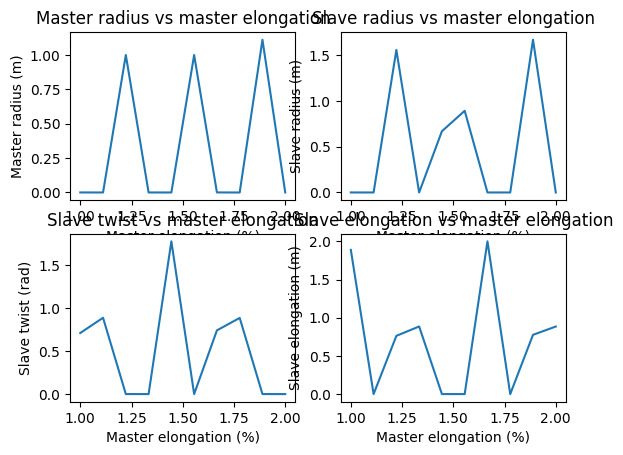

In [81]:
# Plot differences of tube configuration respect to input pressure
plt.subplot(2,2,1)
plt.plot(lbd_a_array, robot_configs[0])
plt.title("Master radius vs master elongation")
plt.xlabel("Master elongation (%)")
plt.ylabel("Master radius (m)")
plt.subplot(2,2,2)
plt.plot(lbd_a_array, robot_configs[3])
plt.title("Slave radius vs master elongation")
plt.xlabel("Master elongation (%)")
plt.ylabel("Slave radius (m)")
plt.subplot(2,2,3)
plt.plot(lbd_a_array, robot_configs[4])
plt.title("Slave twist vs master elongation")
plt.xlabel("Master elongation (%)")
plt.ylabel("Slave twist (rad)")
plt.subplot(2,2,4)
plt.plot(lbd_a_array, robot_configs[5])
plt.title("Slave elongation vs master elongation")
plt.xlabel("Master elongation (%)")
plt.ylabel("Slave elongation (m)")
plt.show()

In [82]:
print(robot_configs[5])

[1.88888889e+00 1.04040706e-04 7.62600899e-01 8.85392849e-01
 2.59017069e-04 0.00000000e+00 2.00000000e+00 1.02659299e-04
 7.75997746e-01 8.84653779e-01]
